### 1. midi 파일 전처리

In [1]:
from util import adjust_to_eighth_note

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
adjusted_notes = adjust_to_eighth_note(file_name)

adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

adjusted_notes_real = adn_1_real + adn_2_real

1th instrument ending : index 2006
2th instrument ending : index 3953


c:\Users\82104\Developments\.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


In [5]:
adjusted_notes_real[:20]

[(0, 67, 1),
 (0, 52, 2),
 (0, 59, 2),
 (0, 62, 2),
 (1, 72, 2),
 (2, 69, 3),
 (2, 74, 3),
 (2, 53, 4),
 (2, 60, 4),
 (3, 81, 4),
 (4, 71, 5),
 (4, 79, 5),
 (4, 55, 6),
 (4, 64, 6),
 (5, 76, 6),
 (6, 67, 7),
 (6, 72, 7),
 (6, 57, 8),
 (6, 64, 8),
 (7, 74, 8)]

* 두 list에서 동시에 연주되는 범위(5~132마디)만 자릅니다.

In [4]:
from util import label_active_chord_by_onset

adn_1_chord = label_active_chord_by_onset(adn_1_real)
adn_2_chord = label_active_chord_by_onset(adn_2_real)

adn_1_chord_ = adn_1_chord[33:] 
adn_2_chord_ = adn_2_chord[:-32]

chord_1_132 = adn_1_chord.copy()
chord_2_132 = [None, *adn_2_chord]
# each of which is of length 1056 (132 bars)

# chord_1_132는 규칙적으로 반복되므로 굳이 solo 파트를 뒤로 붙이지 않아도
# chord_2_132와 원형적 alignness를 보고자 할 때 가능하다.

adn_1_chord_ = chord_1_132[:-32]
adn_2_chord_ = chord_2_132[:-32]

In [6]:
adn_1_chord_[:10], adn_2_chord_[:10]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [None, 0, 1, 2, 3, 4, 5, 6, 7, 8])

In [14]:
# module_chord_label = pd.DataFrame(adn_1_chord[:32])
# module_chord_label.value_counts().to_frame()

* 모듈 1개에서 각 화음의 등장빈도(혹은 지속길이)를 확인하면 위의 결과와 합치함을 알 수 있습니다.

In [7]:
from util import (group_pitches_with_duration_, notes_label_n_counts, 
                  chord_label_to_note_labels, transform_dict, chord_label_dict)

module_notes = adn_1_real[:59]
active_module = group_pitches_with_duration_(module_notes)

notes_label, notes_counts = notes_label_n_counts(module_notes)
chord_label = chord_label_dict(active_module)

# notes = (pitch, duration)
notes_dict = chord_label_to_note_labels(chord_label, notes_label)
pitches_dict = transform_dict(chord_label)
pitch_classes_dict = transform_dict(chord_label, project=True)

In [69]:
notes_label

{(52, 2): 1,
 (53, 2): 2,
 (55, 2): 3,
 (57, 2): 4,
 (57, 6): 5,
 (59, 2): 6,
 (60, 2): 7,
 (60, 6): 8,
 (62, 2): 9,
 (64, 2): 10,
 (64, 6): 11,
 (65, 2): 12,
 (65, 5): 13,
 (65, 6): 14,
 (67, 1): 15,
 (69, 1): 16,
 (69, 5): 17,
 (71, 1): 18,
 (72, 1): 19,
 (74, 1): 20,
 (76, 1): 21,
 (79, 1): 22,
 (81, 1): 23}

In [9]:
print("notes_dict")
for chord, notes in notes_dict.items():
    print(f"{chord}: {notes}")

# print("pitches_dict")
# for chord, pitches in pitches_dict.items():
#     print(f"{chord}: {pitches}")

# print("pitch_classes_dict")
# for chord, pitch_class in pitch_classes_dict.items():
#     print(f"{chord}: {pitch_class}")

notes_dict
0: {9, 15, 6, 1}
1: {9, 19, 6, 1}
2: {16, 2, 20, 7}
3: {2, 23, 7}
4: {10, 18, 3, 22}
5: {10, 3, 21}
6: {10, 19, 4, 15}
7: {10, 4, 20}
8: {16, 12, 21, 6}
9: {19, 12, 6}
10: {8, 20, 14}
11: {8, 17, 14}
12: {10, 4, 21}
13: {16, 20, 12, 6}
14: {18, 12, 6}
15: {19, 11, 5, 15}
16: {5, 11, 13}


* simul distance

In [15]:
# simul 거리공간 정의 및 cycle 탐지 및 대조 용도
from util import get_simul_connected, get_distance_matrix_from, get_LTMpart_of

simul_notes = get_simul_connected(adn_1_chord_, adn_2_chord_, notes_dict)
simul_notes_dist = get_distance_matrix_from(simul_notes)
simul_dist_n = get_LTMpart_of(simul_notes_dist)

# simul_pitches = get_simul_connected(adn_1_chord_, adn_2_chord_, pitches_dict)
# simul_pitch_classes = get_simul_connected(adn_1_chord_, adn_2_chord_, pitch_classes_dict)

Unique values (int keys only): {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23}


In [ ]:
from util import simul_chord_lists, label_simul_chords_combi

simul_chords_key = simul_chord_lists(adn_1_chord_, adn_2_chord_)
labeled_dict = label_simul_chords_combi(simul_chords_key)

for item_set, label in labeled_dict.items():
    print(f"{set(item_set)}: {label}")

{0}: 0
{0, 1}: 1
{1, 2}: 2
{2, 3}: 3
{3, 4}: 4
{4, 5}: 5
{5, 6}: 6
{6, 7}: 7
{8, 7}: 8
{8, 9}: 9
{9, 10}: 10
{10, 11}: 11
{11}: 12
{0, 11}: 13
{12, 6}: 14
{12, 13}: 15
{13, 14}: 16
{14, 15}: 17
{16, 15}: 18
{16}: 19
{0, 16}: 20
{1}: 21
{0, 2}: 22
{1, 3}: 23
{2, 4}: 24
{3, 5}: 25
{4, 6}: 26
{5, 7}: 27
{8, 6}: 28
{9, 7}: 29
{8, 10}: 30
{9, 11}: 31
{1, 11}: 32
{12, 5}: 33
{13, 6}: 34
{12, 14}: 35
{13, 15}: 36
{16, 14}: 37
{16, 1}: 38
{2}: 39
{0, 3}: 40
{1, 4}: 41
{2, 5}: 42
{3, 6}: 43
{4, 7}: 44
{8, 5}: 45
{9, 6}: 46
{10, 7}: 47
{8, 11}: 48
{2, 11}: 49
{12, 4}: 50
{5, 13}: 51
{14, 6}: 52
{12, 15}: 53
{16, 13}: 54
{16, 2}: 55
{3}: 56
{0, 4}: 57
{1, 5}: 58
{2, 6}: 59
{3, 7}: 60
{8, 4}: 61
{9, 5}: 62
{10, 6}: 63
{11, 7}: 64
{11, 3}: 65
{3, 12}: 66
{4, 13}: 67
{5, 14}: 68
{6, 15}: 69
{16, 12}: 70
{16, 3}: 71
{4}: 72
{0, 5}: 73
{1, 6}: 74
{2, 7}: 75
{8, 3}: 76
{9, 4}: 77
{10, 5}: 78
{11, 6}: 79
{11, 4}: 80
{2, 12}: 81
{3, 13}: 82
{4, 14}: 83
{5, 15}: 84
{16, 6}: 85
{16, 4}: 86
{5}: 87
{0, 6}: 

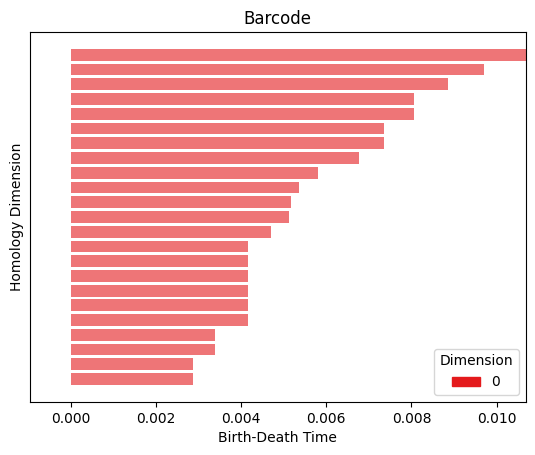

In [23]:
from util import get_persistence, plot_tda_statistics

simplex_tree, persistence = get_persistence(simul_dist_n, max_edge_length = 1, max_dimension = 4)
plot_tda_statistics(simul_dist_n, persistence, dist_distr = False, barcode = True, PD = False)

In [24]:
from util import get_chords_intra_connected, get_chords_inter_connected

weight_mtrx_1 = get_chords_intra_connected(adn_1_chord_, lag=1)
weight_mtrx_2 = get_chords_intra_connected(adn_2_chord_, lag=1)
weight_mtrx = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag=1)

intra_weights = weight_mtrx_1 + weight_mtrx_2
inter_weight = weight_mtrx

notes_dict['name'] = 'notes_dict'
pitches_dict['name'] = 'pitches_dict'
pitch_classes_dict['name'] = 'pitch_classes_dict'

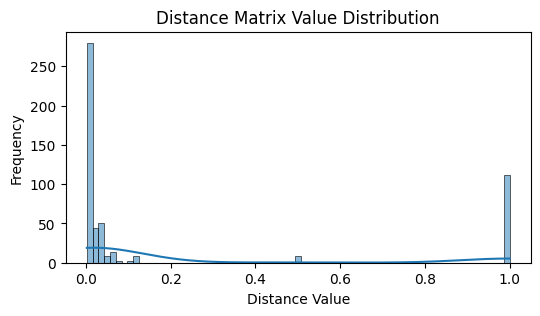

3.035638394754351e-05
0.01232068775928425
0.06848613155005213


In [27]:
import numpy as np
from util import is_distance_matrix_from, plot_dist_distr, get_unique_dist_n_diff

timeflow_weight = inter_weight + intra_weights
timeflow_distance = is_distance_matrix_from(timeflow_weight, notes_dict)

plot_dist_distr(timeflow_distance)

unique_distance, differences = get_unique_dist_n_diff(timeflow_distance)

print(min(differences))
print(np.mean(differences))
print(np.std(differences))

In [79]:
timeflow_distance.iloc[0, 4]

0.00819672131147541

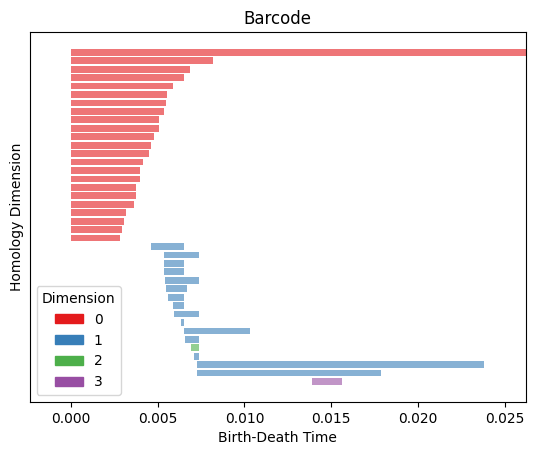

In [36]:
from util import get_cycle_from_distance

(cycle_count, mean, std_dev, longest, cycle_birth_times, 
 lifespans_2d, lifespans_3d) = get_cycle_from_distance(timeflow_distance, barcode = True)

In [82]:
cycle_birth_times.sort()
cycle_birth_times

[0.0045871559633027525,
 0.005376344086021506,
 0.005376344086021506,
 0.005376344086021506,
 0.005434782608695652,
 0.005494505494505495,
 0.0056179775280898875,
 0.0058823529411764705,
 0.005952380952380952,
 0.006369426751592357,
 0.006493506493506494,
 0.006578947368421052,
 0.0070921985815602835,
 0.007246376811594203,
 0.007246376811594203]

on rate 0.0...
on rate 0.01...
on rate 0.02...
on rate 0.03...
on rate 0.04...
on rate 0.05...
on rate 0.06...
on rate 0.07...
on rate 0.08...
on rate 0.09...
on rate 0.1...
on rate 0.11...
on rate 0.12...
on rate 0.13...
on rate 0.14...
on rate 0.15...
on rate 0.16...
on rate 0.17...
on rate 0.18...
on rate 0.19...
on rate 0.2...
on rate 0.21...
on rate 0.22...
on rate 0.23...
on rate 0.24...
on rate 0.25...
on rate 0.26...
on rate 0.27...
on rate 0.28...
on rate 0.29...
on rate 0.3...
on rate 0.31...
on rate 0.32...
on rate 0.33...
on rate 0.34...
on rate 0.35...
on rate 0.36...
on rate 0.37...
on rate 0.38...
on rate 0.39...
on rate 0.4...
on rate 0.41...
on rate 0.42...
on rate 0.43...
on rate 0.44...
on rate 0.45...
on rate 0.46...
on rate 0.47...
on rate 0.48...
on rate 0.49...
on rate 0.5...
on rate 0.51...
on rate 0.52...
on rate 0.53...
on rate 0.54...
on rate 0.55...
on rate 0.56...
on rate 0.57...
on rate 0.58...
on rate 0.59...
on rate 0.6...
on rate 0.61...
on rate 0.62...

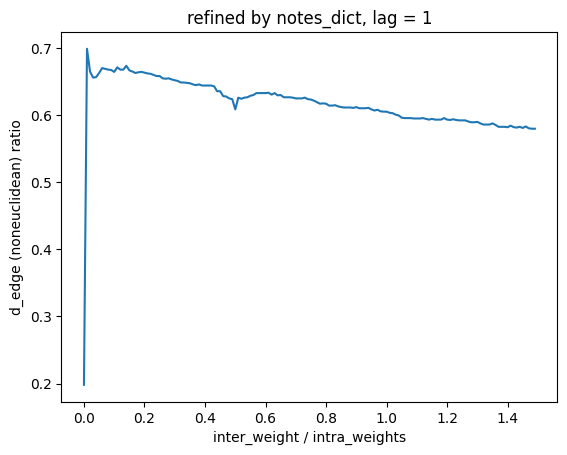

In [35]:
from util import find_non_triangle_inequality, plot_d_edge_ratio, plot_cycles_profile, plot_higher_homol

def search_optimal_rate_n_dict(intra_weights, inter_lag : int = 1, refine_dict : dict = notes_dict,
                                rate_start = 0.00, rate_end = 1.5, step = 0.01,
                                loglog : bool = False, only_d_edge : bool = False) :
    
    # rate_start = 0.01, 0.02는 사소한 에러가 생겨서 스킵.
    inter_weight = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag=inter_lag)
    
    start = round(rate_start / step)
    end = round(rate_end / step)

    cycles_profile = []
    cycles_births = []
    higher_homol = []
    d_edge_ratios = []

    for a in range(start, end, 1) :
        rate = round(a * step, 4)
        print(f"on rate {rate}...")

        timeflow_weight = intra_weights + rate * inter_weight 
        timeflow_distance = is_distance_matrix_from(timeflow_weight, refine_dict)
        noneuclidean_ratio = find_non_triangle_inequality(timeflow_distance)

        result_0 = (rate, noneuclidean_ratio)
        d_edge_ratios.append(result_0)

        if not only_d_edge : 

            (count, mean, std_dev, longest, cycle_birth_times, 
            lifespans_2d, lifespans_3d) = get_cycle_from_distance(timeflow_distance)

            result_1 = (rate, count, mean, std_dev, longest)
            cycles_profile.append(result_1)

            result_2 = (rate, lifespans_2d, lifespans_3d)
            higher_homol.append(result_2)

            result_3 = (rate, cycle_birth_times)
            cycles_births.append(result_3)

    plot_d_edge_ratio(d_edge_ratios = d_edge_ratios, refine_dict = refine_dict, inter_lag = inter_lag)

    if not only_d_edge :

        plot_cycles_profile(cycles_profile = cycles_profile, refine_dict = refine_dict, inter_lag = inter_lag, loglog = loglog)

        plot_higher_homol(higher_homol = higher_homol, refine_dict = refine_dict, inter_lag = inter_lag)

    return d_edge_ratios, cycles_profile, cycles_births, higher_homol

# (cycles_info_n1, cycles_vertices_n1, cycles_births_n1, cycles_edges_n1) = 
(d_edge_ratio_n1, cycles_profile_n1, cycles_births_n1, higher_homol_n1) = search_optimal_rate_n_dict(intra_weights, loglog=True, step = 0.01, only_d_edge=True)

In [83]:
# timeflow_distance.to_csv('distance_matrix.csv', index=True, header=False)

# .mat 파일로 저장
import scipy.io
distances = timeflow_distance.to_numpy()
scipy.io.savemat('distance_matrix.mat', {'distances': distances})

In [77]:
distances = timeflow_distance.to_numpy()

distances.min()

0.0020242914979757085

### 2. Zipf's Law

In [37]:
import pandas as pd

# Counter 객체를 리스트로 변환
data = list(notes_counts.items())
combination_counts_df = pd.DataFrame(data, columns=['Combination', 'Count'])
combination_counts_df

,Combination,Count
0,"(67, 1)",5
1,"(52, 2)",2
2,"(59, 2)",4
3,"(62, 2)",2
4,"(72, 1)",6
5,"(69, 1)",4
6,"(74, 1)",5
7,"(53, 2)",2
8,"(60, 2)",2
9,"(81, 1)",2


In [38]:
import matplotlib.pyplot as plt

# 각 조합의 등장 횟수를 계산 (논문에서 말하는 frequency에 해당)
frequency_counts = combination_counts_df.copy()
frequency_counts.columns = ['Combination', 'Frequency']

# 빈도수를 기준으로 내림차순 정렬
frequency_counts = frequency_counts.sort_values(by='Frequency', ascending=False)

# rank 부여
frequency_counts['Rank'] = range(1, len(frequency_counts) + 1)
frequency_counts

,Combination,Frequency,Rank
4,"(72, 1)",6,1
0,"(67, 1)",5,2
6,"(74, 1)",5,3
2,"(59, 2)",4,4
5,"(69, 1)",4,5
14,"(76, 1)",4,6
13,"(64, 2)",4,7
10,"(71, 1)",3,8
12,"(55, 2)",2,9
16,"(65, 2)",2,10


In [ ]:
from util import find_multilength_pitches

frequent_pitches = find_multilength_pitches(notes_counts)
print("\n서로 다른 length를 갖는 조합으로 2번 이상 등장한 Notes:")
frequent_pitches


서로 다른 length를 갖는 조합으로 2번 이상 등장한 Notes:


{69: 2, 60: 2, 64: 2, 57: 2, 65: 3}

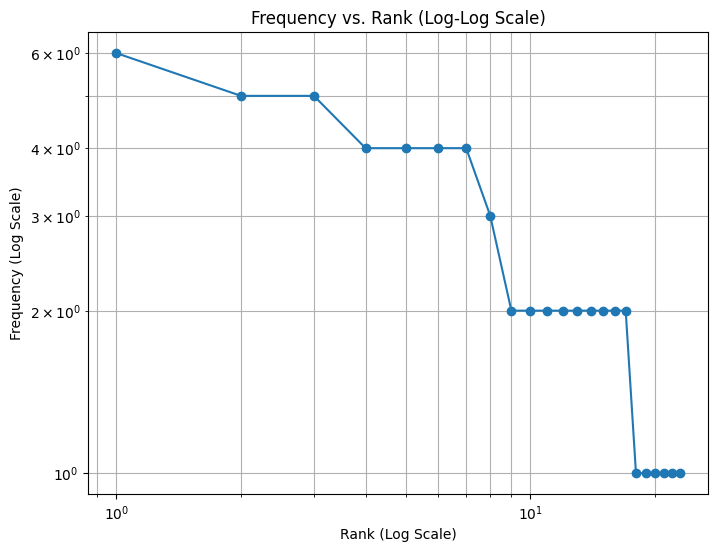

In [40]:
plt.figure(figsize=(8, 6))
plt.loglog(frequency_counts['Rank'], frequency_counts['Frequency'], marker='o', linestyle='-')
plt.xlabel("Rank (Log Scale)")
plt.ylabel("Frequency (Log Scale)")
plt.title("Frequency vs. Rank (Log-Log Scale)")
plt.grid(True, which="both", ls="-")
plt.show()

C:\Users\82104\AppData\Local\Temp\ipykernel_25444\4291018205.py:5: RuntimeWarning: invalid value encountered in power
  return 1 / (a + b * r)**z


최적화된 파라미터: a=0.612, b=0.017, z=3.828


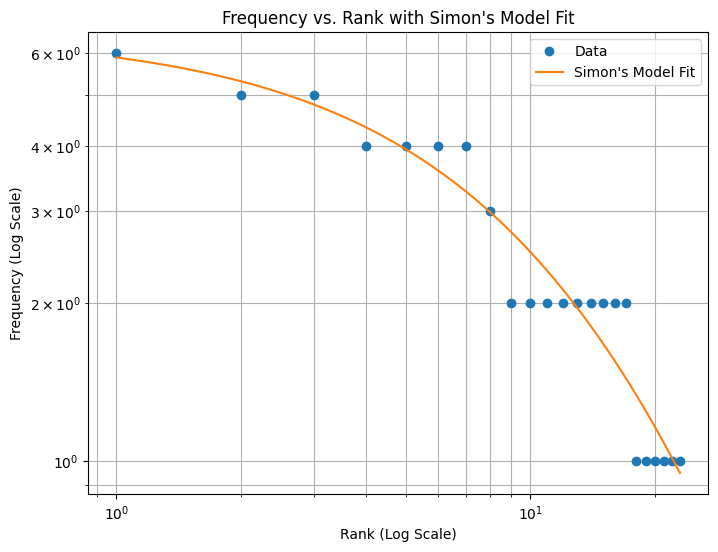

In [42]:
from scipy.optimize import curve_fit


def simons_model(r, a, b, z):
    return 1 / (a + b * r)**z

frequency = frequency_counts['Frequency']
frequency = np.array(frequency)

rank = frequency_counts['Rank']
rank = np.array(rank)

# 초기 추정
initial_guess = [1, 1, 1]  # a, b, z에 대한 초기값

# curve_fit 실행
popt, pcov = curve_fit(simons_model, rank, frequency, p0=initial_guess)

# 결과 출력
a_opt, b_opt, z_opt = popt
print(f"최적화된 파라미터: a={a_opt:.3f}, b={b_opt:.3f}, z={z_opt:.3f}")

# fitting된 곡선 생성
rank_fit = np.linspace(min(rank), max(rank), 100)
frequency_fit = simons_model(rank_fit, a_opt, b_opt, z_opt)

# 플롯
plt.figure(figsize=(8, 6))
plt.loglog(rank, frequency, 'o', label="Data")
plt.loglog(rank_fit, frequency_fit, '-', label="Simon's Model Fit")

plt.xlabel("Rank (Log Scale)")
plt.ylabel("Frequency (Log Scale)")
plt.title("Frequency vs. Rank with Simon's Model Fit")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

첫 번째 구간 기울기: -0.273, R-squared: 0.842
두 번째 구간 기울기: -0.965, R-squared: 0.658


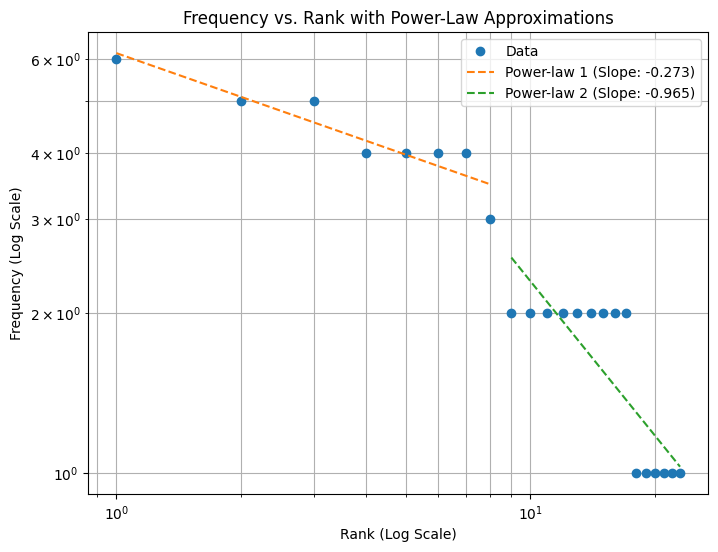

In [64]:
from scipy.stats import linregress


#%%
# 꺾이는 점을 시각적으로 추정 (예시: 순위 8 근처)
break_point = 8

# 첫 번째 구간
rank_1 = np.log(rank[:break_point])
frequency_1 = np.log(frequency[:break_point])
slope_1, intercept_1, r_value_1, p_value_1, std_err_1 = linregress(rank_1, frequency_1)
print(f"첫 번째 구간 기울기: {slope_1:.3f}, R-squared: {r_value_1**2:.3f}")

# 두 번째 구간
rank_2 = np.log(rank[break_point:])
frequency_2 = np.log(frequency[break_point:])
slope_2, intercept_2, r_value_2, p_value_2, std_err_2 = linregress(rank_2, frequency_2)
print(f"두 번째 구간 기울기: {slope_2:.3f}, R-squared: {r_value_2**2:.3f}")

# 플롯
plt.figure(figsize=(8, 6))
plt.loglog(rank, frequency, 'o', label="Data")

# Power-law 1
rank_fit_1 = np.linspace(min(rank), rank[break_point-1], 50)
frequency_fit_1 = np.exp(intercept_1 + slope_1 * np.log(rank_fit_1))
plt.loglog(rank_fit_1, frequency_fit_1, '--', label=f"Power-law 1 (Slope: {slope_1:.3f})")

# Power-law 2
rank_fit_2 = np.linspace(rank[break_point], max(rank), 50)
frequency_fit_2 = np.exp(intercept_2 + slope_2 * np.log(rank_fit_2))
plt.loglog(rank_fit_2, frequency_fit_2, '--', label=f"Power-law 2 (Slope: {slope_2:.3f})")

plt.xlabel("Rank (Log Scale)")
plt.ylabel("Frequency (Log Scale)")
plt.title("Frequency vs. Rank with Power-Law Approximations")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()


In [49]:
from piecewise_regression.models import PiecewiseLinFit

# Piecewise Linear Fit 모델 생성
pwlf = PiecewiseLinFit(rank, frequency)

# 최적의 breakpoint 개수 찾기 (AIC 사용)
res = pwlf.fit_with_breaks([4, 10])  # 초기 breakpoint 추정값
print(f"최적의 breakpoint 위치: {pwlf.fit_breaks}")

# 결과 시각화
plt.figure(figsize=(8, 6))
plt.plot(rank, frequency, 'o', label='Data')
plt.plot(rank, pwlf.predict(rank), '-', label='Piecewise Linear Fit')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'piecewise_regression.models'

### 3. DFT (Discrete Fourier Transform)

In [ ]:
# import util
# import importlib
# importlib.reload(util)
from util import FourierBars, group_indices_by_element_lists, FourierMetricNorm

# just_bars_1 = FourierBars(adn_1_real, distinct=False)
just_bars_2 = FourierBars(adn_2_real, distinct=False)
just_bars_2[:5] # adn_2_real가 5번째 마디부터 시작해서 처음 4개 list가 비어있다.
# len(just_bars_1), len(just_bars_2) # (132, 136)

48


[[],
 [],
 [],
 [],
 [[1, 19],
  [1, 4],
  [1, 11],
  [1, 14],
  [2, 24],
  [3, 21],
  [3, 26],
  [3, 5],
  [3, 12],
  [4, 33],
  [5, 23],
  [5, 31],
  [5, 7],
  [5, 16],
  [6, 28],
  [7, 19],
  [7, 24],
  [7, 9],
  [7, 16]]]

In [ ]:
# inst 2에서 반복되는 고윳값 자체는 29개이고
# inst 1에서 반복되는 4개(모듈 : A, B, A', C)와 겹쳐질 때 5~132마디 까지 반복되는 조합은 없다.
grouped_indices = group_indices_by_element_lists(just_bars_2)
grouped_indices 

{0: [0, 1, 2, 3],
 1: [4, 6, 37, 39, 70, 72, 103, 105],
 2: [5, 38, 71, 104],
 3: [7, 40, 73, 106],
 4: [8, 10, 41, 43, 74, 76, 107, 109],
 5: [9, 42, 75, 108],
 6: [11, 44, 77, 110],
 7: [12, 14, 45, 47, 78, 80, 111, 113],
 8: [13, 46, 79, 112],
 9: [15, 48, 81, 114],
 10: [16, 18, 49, 51, 82, 84, 115, 117],
 11: [17, 50, 83, 116],
 12: [19, 52, 85, 118],
 13: [20, 53, 86, 119],
 14: [21, 54, 87, 120],
 15: [22, 55, 88, 121],
 16: [23, 56, 89, 122],
 17: [24, 57, 90, 123],
 18: [25, 58, 91, 124],
 19: [26, 59, 92, 125],
 20: [27, 60, 93, 126],
 21: [28, 61, 94, 127],
 22: [29, 62, 95, 128],
 23: [30, 63, 96, 129],
 24: [31, 64, 97, 130],
 25: [32, 65, 98, 131],
 26: [33, 66, 99, 132],
 27: [34, 67, 100, 133],
 28: [35, 68, 101, 134],
 29: [36, 69, 102, 135]}

In [63]:
# unique_bars_1 = FourierBars(adn_1_real, distinct=True)
unique_bars_2 = FourierBars(adn_2_real, distinct=True)
# len(unique_bars_1), len(unique_bars_2) # (4, 29)

distance_bars = FourierMetricNorm(unique_bars_2, fill = False)

for i in distance_bars.keys() :
    print(f"{i} / 100 : {distance_bars[i]}")

0 / 100 : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
19 / 100 : [(13, 15)]
24 / 100 : [(26, 28)]
30 / 100 : [(17, 19), (22, 24)]
40 / 100 : [(18, 20)]
42 / 100 : [(21, 23)]
56 / 100 : [(25, 27)]
57 / 100 : [(17, 25)]
59 / 100 : [(14, 16), (27, 29)]
60 / 100 : [(8, 25)]
61 / 100 : [(9, 25), (17, 27)]
62 / 100 : [(17, 29)]
63 / 100 : [(2, 3), (2, 29), (5, 6), (8, 9), (11, 12), (17, 21), (17, 23), (21, 25)]
64 / 100 : [(2, 19), (5, 21), (13, 17), (13, 25), (19, 29)]
65 / 100 : [(6, 21), (10, 25), (19, 23), (19, 25), (23, 25), (25, 29)]
66 / 100 : [(3, 23)]
67 / 100 : [(2, 17), (3, 17), (3, 25), (8, 27), (15, 25), (19, 27)]
68 / 100 : [(2, 23), (2, 25), (2, 27), (10, 13), (10, 17), (13, 19), (15, 17), (15, 27), (15, 29)]
69 / 100 : [(2, 21), (3, 19), (3, 21), (5, 23), (13, 23), (13, 29)]
70 / 100 : [(3, 29), (6, 25), (13, 21), (23, 27)]
71 / 100 : [(3, 27), (10, 15), (10, 21), (10, 23), (13, 27), (15, 19), (15, 23), (19, 21),